# Analyse des maillages `ville*.ply` — caractérisation des graphes pour le ML

Les fichiers `dataset/blender/ville*.ply` sont les **maillages urbains bruts** qui
servent de géométrie d'entrée au pipeline. Avant d'y faire tourner un GNN, ce
notebook répond à : **quel type de graphe est-ce, quelles sont ses dimensions, et
qu'est-ce qui compte pour du machine learning sur graphes ?**

### Du maillage au graphe
Chaque maillage est une **surface triangulée** (sommets + faces triangulaires).
Le pipeline GAT transforme chaque maillage en graphe ainsi :

- **nœud = face** (triangle) du maillage,
- **arête = deux faces partageant une arête géométrique** (adjacence 1-ring).

C'est exactement la construction de `dataio._face_adjacency`. On reproduit ici la
même logique (parser + adjacence) de façon autonome, puis on mesure les
propriétés du graphe pertinentes pour un GNN : **taille, degré, densité,
composantes connexes, diamètre, manifoldness**.

> Note : ces maillages bruts ne portent **pas** de labels (la couleur/classe est
> ajoutée par la simulation acoustique, cf. `NoiseMap_*.ply`). On caractérise donc
> la **structure** du graphe, pas l'homophilie des étiquettes.

## 0 — Configuration & parser PLY

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components, shortest_path

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

BLENDER_DIR = Path("/home/ldena/Bureau/PIR-local/PIR/dataset/blender")
if not BLENDER_DIR.exists():                       # fallback relatif
    BLENDER_DIR = (Path.cwd() / "../../../dataset/blender").resolve()
ply_files = sorted(BLENDER_DIR.glob("ville*.ply"))
print(f"{len(ply_files)} maillages dans {BLENDER_DIR}")
for p in ply_files:
    print("  ", p.name)

11 maillages dans /home/ldena/Bureau/PIR-local/PIR/dataset/blender
   ville.ply
   ville10.ply
   ville2.ply
   ville3.ply
   ville4.ply
   ville5.ply
   ville6.ply
   ville7.ply
   ville8.ply
   ville9.ply
   ville_noisemap.ply


In [ ]:
def parse_ply(path):
    """Parser PLY ASCII minimal. Retourne (verts (N,3), faces (M,3), group (N,)).

    Reproduit dataio._parse_ply pour rester autonome (pas d'import torch_geometric,
    qui forcerait le backend matplotlib 'Agg' et casserait l'affichage inline)."""
    with open(path) as f:
        assert f.readline().strip() == "ply"
        elements, current = [], None
        while True:
            line = f.readline().strip()
            if line == "end_header":
                break
            if line.startswith(("comment", "format", "obj_info")):
                continue
            t = line.split()
            if t[0] == "element":
                if current: elements.append(current)
                current = (t[1], int(t[2]), [])
            elif t[0] == "property" and current:
                current[2].append((t[-1], t[1] == "list"))
        if current: elements.append(current)

        verts = faces = group = None
        for name, n, props in elements:
            names = [p[0] for p in props]
            if name == "vertex":
                ix, iy, iz = names.index("x"), names.index("y"), names.index("z")
                ig = names.index("Group") if "Group" in names else None
                arr = np.empty((n, 3), np.float32)
                grp = np.zeros(n, np.float32)
                for i in range(n):
                    tok = f.readline().split()
                    arr[i] = float(tok[ix]), float(tok[iy]), float(tok[iz])
                    if ig is not None: grp[i] = float(tok[ig])
                verts, group = arr, grp
            elif name == "face":
                fa = np.empty((n, 3), np.int64)
                for i in range(n):
                    tok = f.readline().split()
                    k = int(tok[0])                # nb de sommets (3 = triangle)
                    fa[i] = int(tok[1]), int(tok[2]), int(tok[3])
                faces = fa
            else:
                for _ in range(n): f.readline()
    return verts, faces, group


def face_edges(faces):
    """(3M, 2) arêtes triées (v_min, v_max), une par côté de triangle.
    Brique commune à l'adjacence des faces et au test de manifoldness."""
    return np.concatenate([
        np.sort(faces[:, [0, 1]], axis=1),
        np.sort(faces[:, [1, 2]], axis=1),
        np.sort(faces[:, [0, 2]], axis=1),
    ], axis=0)


def face_adjacency(faces):
    """edge_index (2,E) symétrique entre faces partageant une arête (cf. dataio)."""
    n = faces.shape[0]
    e = face_edges(faces)
    fid = np.tile(np.arange(n), 3)
    order = np.lexsort((e[:, 1], e[:, 0]))
    e_s, fid_s = e[order], fid[order]
    eq = (e_s[1:, 0] == e_s[:-1, 0]) & (e_s[1:, 1] == e_s[:-1, 1])
    src, dst = fid_s[:-1][eq], fid_s[1:][eq]
    s = np.concatenate([src, dst]); d = np.concatenate([dst, src])
    keep = s != d
    pairs = np.unique(np.stack([s[keep], d[keep]], 1), axis=0)
    return pairs.T


## 1 — Passage sur les maillages : géométrie + métriques de graphe

In [ ]:
def approx_diameter(csr, comp_mask):
    """Diamètre approché (double balayage BFS) sur la plus grande composante."""
    idx = np.where(comp_mask)[0]
    if idx.size < 2:
        return 0
    sub = csr[idx][:, idx]
    d0 = shortest_path(sub, method="D", unweighted=True, indices=0)
    a = int(np.argmax(np.where(np.isfinite(d0), d0, -1)))
    da = shortest_path(sub, method="D", unweighted=True, indices=a)
    return int(np.nanmax(np.where(np.isfinite(da), da, np.nan)))

rows, degree_samples, edgemult_samples = [], {}, {}
for p in ply_files:
    verts, faces, group = parse_ply(p)
    N = faces.shape[0]

    # Graphe d'adjacence des faces -> matrice creuse symétrique.
    ei = face_adjacency(faces)
    E = ei.shape[1] // 2                                   # arêtes non orientées
    A = sp.coo_matrix((np.ones(ei.shape[1]), (ei[0], ei[1])), shape=(N, N)).tocsr()
    deg = np.asarray(A.sum(axis=1)).ravel()

    # Composantes connexes (portée du message passing).
    n_comp, comp = connected_components(A, directed=False)
    sizes = np.bincount(comp)
    big = sizes.argmax()

    # Manifoldness : combien de faces partagent chaque arête géométrique.
    _, mult = np.unique(face_edges(faces), axis=0, return_counts=True)

    # Dimensions géométriques (bbox). Échelle maillage : 1 unité ≈ 100 m.
    lo, hi = verts.min(0), verts.max(0)
    ext = hi - lo

    rows.append({
        "ville": p.stem,
        "n_verts": verts.shape[0], "n_faces": N,
        "n_edges": E, "deg_moy": deg.mean(), "deg_max": int(deg.max()),
        "isoles": int((deg == 0).sum()),
        "densite": 2 * E / (N * (N - 1)),
        "n_composantes": int(n_comp),
        "frac_plus_grande": sizes[big] / N,
        "diam_approx": approx_diameter(A, comp == big),
        "ext_x": ext[0], "ext_y": ext[1], "ext_z": ext[2],
        "bord_%": 100 * (mult == 1).mean(),
        "manifold_%": 100 * (mult == 2).mean(),
        "non_manifold_%": 100 * (mult > 2).mean(),
        "n_groups": int(np.unique(np.round(group, 4)).size),
    })
    degree_samples[p.stem] = deg
    edgemult_samples[p.stem] = mult
    print(f"  {p.stem:<16} N={N:>6} faces  E={E:>7}  comp={n_comp:>3}  "
          f"diam≈{rows[-1]['diam_approx']}")

g = pd.DataFrame(rows).set_index("ville")
print("\nTerminé.")

  ville            N= 36275 faces  E=  50514  comp=197  diam≈273
  ville10          N= 18939 faces  E=  26858  comp= 92  diam≈272
  ville2           N= 23663 faces  E=  33468  comp=138  diam≈273


  ville3           N= 38625 faces  E=  53655  comp=248  diam≈272
  ville4           N= 29179 faces  E=  40956  comp=153  diam≈272


  ville5           N= 22889 faces  E=  32447  comp=114  diam≈272
  ville6           N= 17367 faces  E=  25081  comp= 32  diam≈272


  ville7           N= 33909 faces  E=  47327  comp=188  diam≈273
  ville8           N= 31531 faces  E=  44156  comp=157  diam≈272


  ville9           N= 28911 faces  E=  39671  comp=201  diam≈275
  ville_noisemap   N= 36275 faces  E=  54259  comp=  1  diam≈273

Terminé.


## 2 — Dimensions des graphes (sommets, faces=nœuds, arêtes)

,n_verts,n_faces,n_edges,deg_moy,deg_max,densite
ville,,,,,,
ville,"22,037","36,275","50,514",2.79,3,7.68e-05
ville10,"11,025","18,939","26,858",2.84,3,1.50e-04
ville2,"13,859","23,663","33,468",2.83,3,1.20e-04
ville3,"23,596","38,625","53,655",2.78,3,7.19e-05
ville4,"17,403","29,179","40,956",2.81,3,9.62e-05
ville5,"13,332","22,889","32,447",2.84,3,1.24e-04
ville6,"9,654","17,367","25,081",2.89,3,1.66e-04
ville7,"20,492","33,909","47,327",2.79,3,8.23e-05
ville8,"18,907","31,531","44,156",2.80,3,8.88e-05


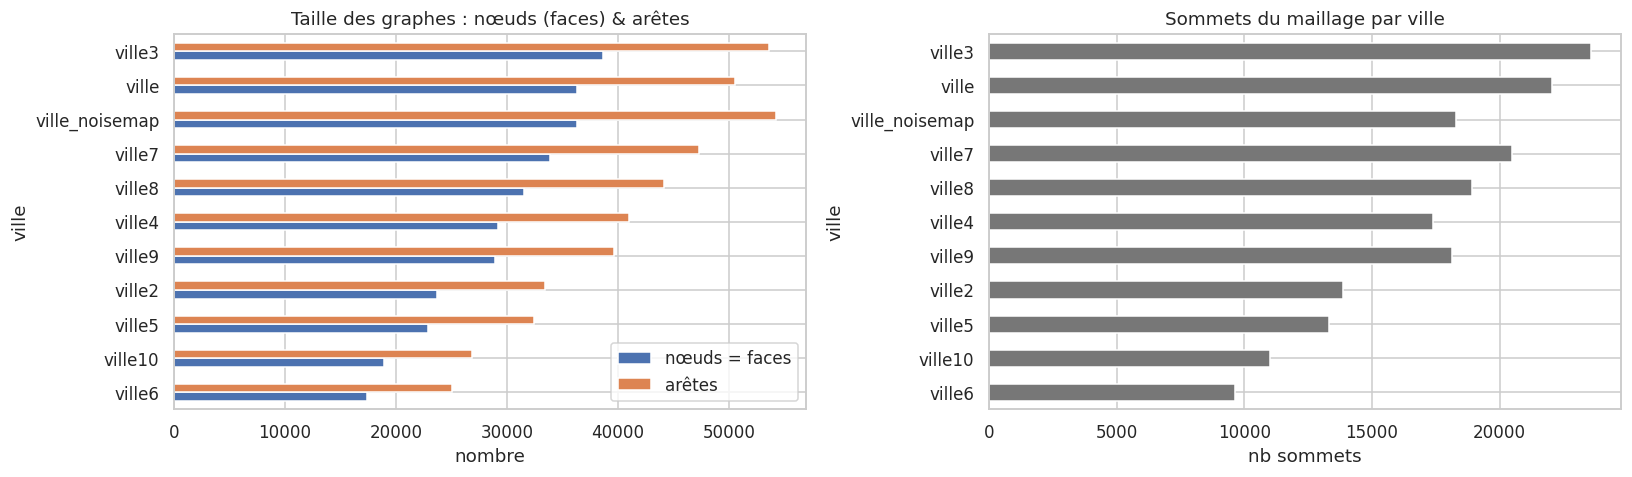

Graphes : de 17,367 à 38,625 nœuds (médiane 29,179).
Total cumulé : 317,563 nœuds, 448,392 arêtes.


In [ ]:
show = g[["n_verts", "n_faces", "n_edges", "deg_moy", "deg_max", "densite"]]
display(show.style.format({"n_verts": "{:,}", "n_faces": "{:,}", "n_edges": "{:,}",
                           "deg_moy": "{:.2f}", "densite": "{:.2e}"}))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
g_sorted = g.sort_values("n_faces")
g_sorted[["n_faces", "n_edges"]].plot.barh(ax=ax[0])
ax[0].set(title="Taille des graphes : nœuds (faces) & arêtes", xlabel="nombre")
ax[0].legend(["nœuds = faces", "arêtes"])
g_sorted["n_verts"].plot.barh(ax=ax[1], color="#777")
ax[1].set(title="Sommets du maillage par ville", xlabel="nb sommets")
plt.tight_layout(); plt.show()

print(f"Graphes : de {g.n_faces.min():,} à {g.n_faces.max():,} nœuds "
      f"(médiane {int(g.n_faces.median()):,}).")
print(f"Total cumulé : {g.n_faces.sum():,} nœuds, {g.n_edges.sum():,} arêtes.")

## 3 — Type de graphe : degré & densité

Pour un maillage triangulaire **2-manifold**, chaque triangle a au plus **3
voisins** (un par côté). On s'attend donc à un graphe **très creux**, à **degré
borné ≈ 3**, proche d'un graphe planaire — un régime idéal et bénin pour un GNN
(pas de nœuds hubs, message passing local homogène).

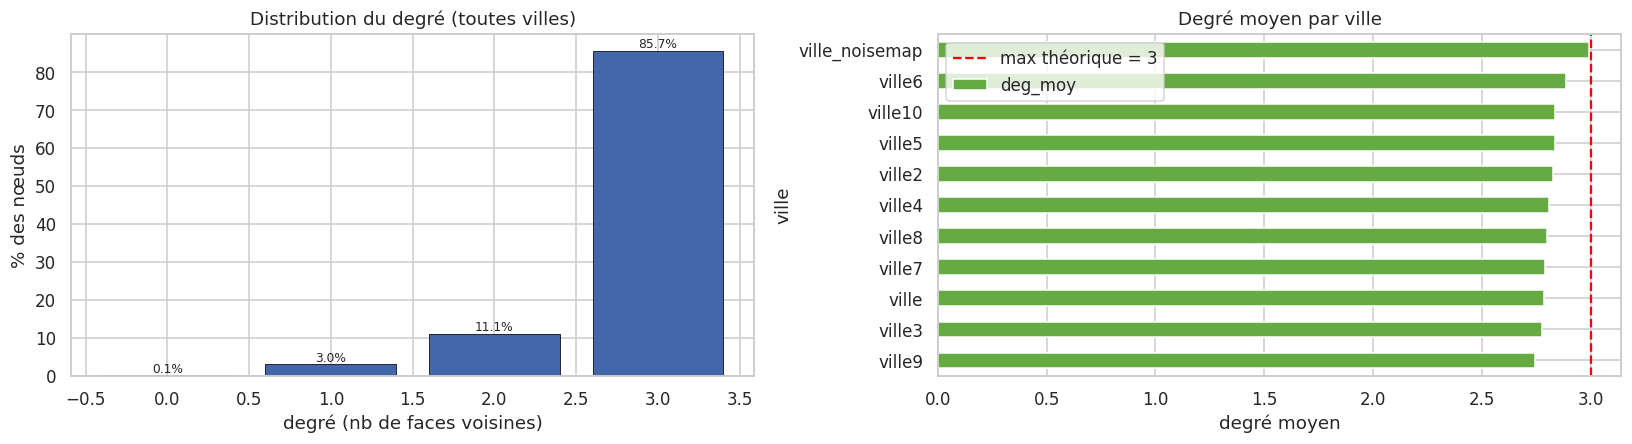

Degré moyen global ≈ 2.82  |  densité ~ 1.0e-04 (graphe très creux)
Nœuds isolés (degré 0) au total : 415


In [ ]:
all_deg = np.concatenate(list(degree_samples.values()))
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
vals, cnts = np.unique(all_deg, return_counts=True)
ax[0].bar(vals, 100 * cnts / cnts.sum(), color="#46a", edgecolor="black", lw=.5)
ax[0].set(title="Distribution du degré (toutes villes)", xlabel="degré (nb de faces voisines)",
          ylabel="% des nœuds")
for v, c in zip(vals, cnts):
    ax[0].text(v, 100*c/cnts.sum(), f"{100*c/cnts.sum():.1f}%", ha="center", va="bottom", fontsize=8)

g.sort_values("deg_moy")["deg_moy"].plot.barh(ax=ax[1], color="#6a4")
ax[1].axvline(3, color="red", ls="--", label="max théorique = 3")
ax[1].set(title="Degré moyen par ville", xlabel="degré moyen"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Degré moyen global ≈ {all_deg.mean():.2f}  |  densité ~ {g.densite.mean():.1e} (graphe très creux)")
print(f"Nœuds isolés (degré 0) au total : {int((all_deg==0).sum())}")

## 4 — Connectivité & diamètre (portée du message passing)

Deux quantités décisives pour dimensionner un GNN :

- **Composantes connexes** : si le maillage se fragmente (bâtiments séparés du
  sol, îlots), l'information ne circule pas entre composantes — un GNN ne peut
  rien propager d'une à l'autre.
- **Diamètre** (en sauts) : nombre de couches nécessaire pour qu'un nœud « voie »
  l'autre bout du graphe. Un diamètre de *D* signifie qu'un champ réceptif global
  exigerait ~*D* couches — souvent >> profondeur réaliste, d'où la nécessité de
  features géométriques **globales** (distance/angle à la source) plutôt que de
  compter sur la seule propagation locale.

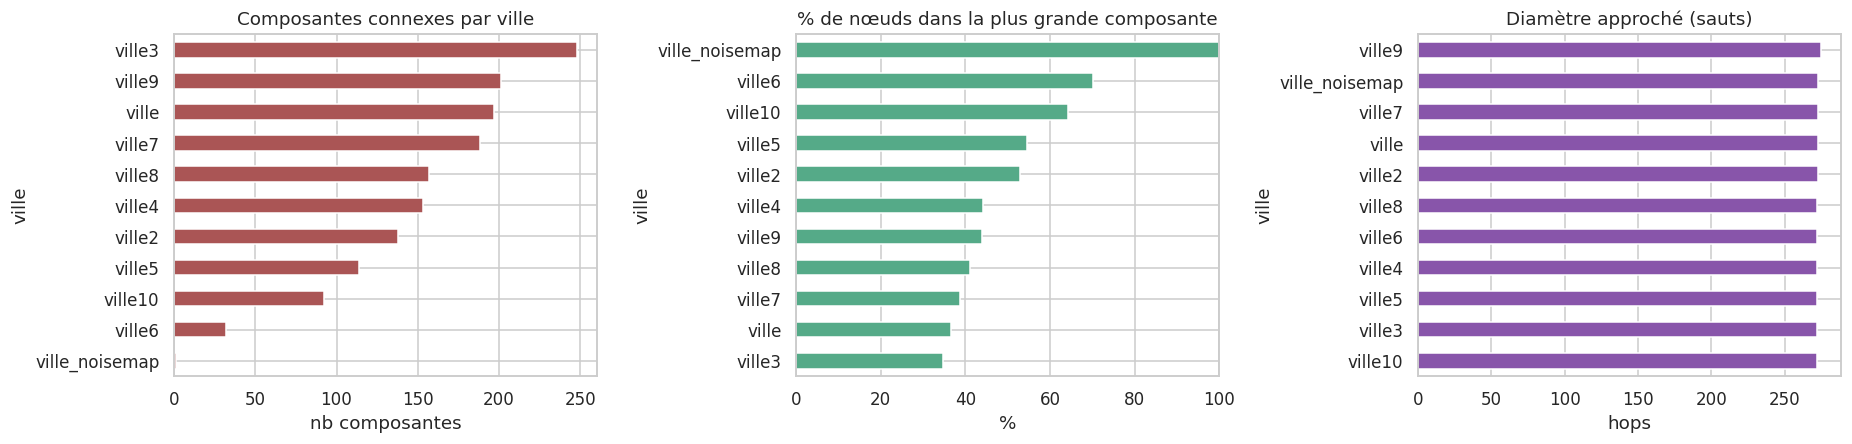

,n_composantes,frac_plus_grande,diam_approx,isoles
ville,,,,
ville,197,0.366,273,56
ville10,92,0.643,272,17
ville2,138,0.529,273,45
ville3,248,0.347,272,76
ville4,153,0.441,272,46
ville5,114,0.546,272,33
ville6,32,0.701,272,8
ville7,188,0.386,273,48
ville8,157,0.412,272,39


Diamètre médian ≈ 272 sauts → un champ réceptif global demanderait ~autant de couches GNN.


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
g.sort_values("n_composantes")["n_composantes"].plot.barh(ax=ax[0], color="#a55")
ax[0].set(title="Composantes connexes par ville", xlabel="nb composantes")
(100*g.sort_values("frac_plus_grande")["frac_plus_grande"]).plot.barh(ax=ax[1], color="#5a8")
ax[1].set(title="% de nœuds dans la plus grande composante", xlabel="%"); ax[1].set_xlim(0, 100)
g.sort_values("diam_approx")["diam_approx"].plot.barh(ax=ax[2], color="#85a")
ax[2].set(title="Diamètre approché (sauts)", xlabel="hops")
plt.tight_layout(); plt.show()

display(g[["n_composantes", "frac_plus_grande", "diam_approx", "isoles"]]
        .style.format({"frac_plus_grande": "{:.3f}"}))
print(f"Diamètre médian ≈ {int(g.diam_approx.median())} sauts → "
      f"un champ réceptif global demanderait ~autant de couches GNN.")

## 5 — Manifoldness (qualité topologique du maillage)

Combien de faces partagent chaque arête géométrique ?
- **2** → arête intérieure d'une surface 2-manifold propre (cas attendu).
- **1** → arête de **bord** (silhouette, trou, ou frontière du patch).
- **>2** → arête **non-manifold** (T-jonctions, faces collées) : peut créer des
  voisinages anormaux dans le graphe et mérite attention avant l'entraînement.

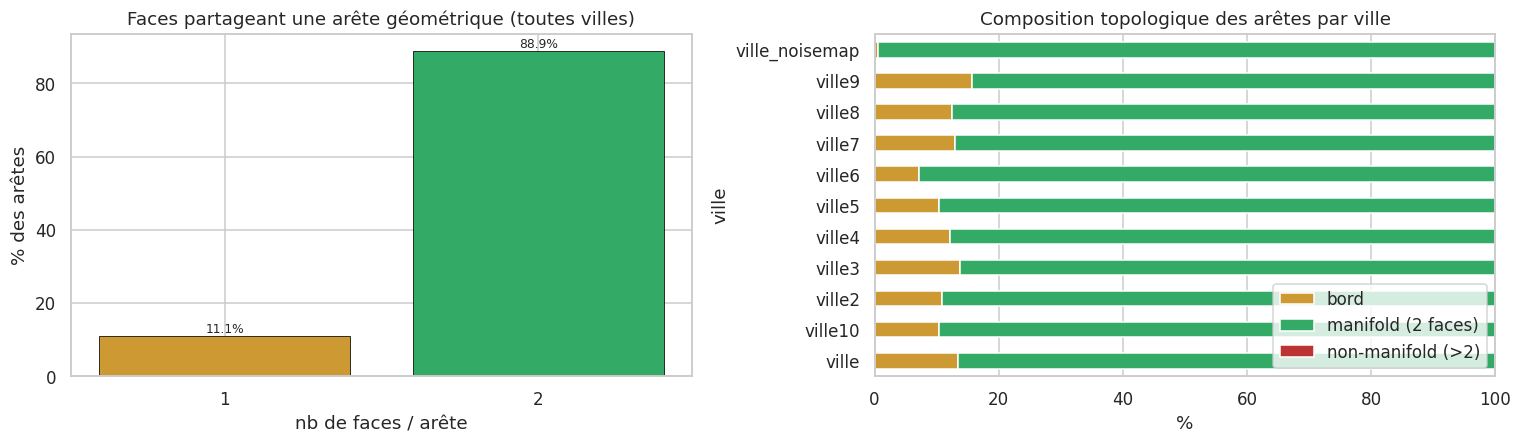

Arêtes non-manifold (>2 faces) : 0.00% du total


In [7]:
all_mult = np.concatenate(list(edgemult_samples.values()))
vals, cnts = np.unique(all_mult, return_counts=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].bar([str(v) for v in vals], 100*cnts/cnts.sum(),
          color=["#c93", "#3a6", "#b33", "#933"][:len(vals)], edgecolor="black", lw=.5)
ax[0].set(title="Faces partageant une arête géométrique (toutes villes)",
          xlabel="nb de faces / arête", ylabel="% des arêtes")
for i, (v, c) in enumerate(zip(vals, cnts)):
    ax[0].text(i, 100*c/cnts.sum(), f"{100*c/cnts.sum():.1f}%", ha="center", va="bottom", fontsize=8)

g[["bord_%", "manifold_%", "non_manifold_%"]].plot.barh(stacked=True, ax=ax[1],
        color=["#c93", "#3a6", "#b33"])
ax[1].set(title="Composition topologique des arêtes par ville", xlabel="%")
ax[1].legend(["bord", "manifold (2 faces)", "non-manifold (>2)"], loc="lower right")
plt.tight_layout(); plt.show()
print(f"Arêtes non-manifold (>2 faces) : {100*(all_mult>2).mean():.2f}% du total")

## 6 — Dimensions géométriques & empreinte spatiale

L'échelle du maillage est **1 unité ≈ 100 m**. La bbox donne l'emprise au sol
(x, y) et la **hauteur de la scène** (z) — utile pour normaliser les features
géométriques et calibrer le rayon de réflexion (`REFLECT_RADIUS`).

,étendue_x,étendue_y,hauteur_z,n_groups
ville,,,,
ville,40.00,40.00,6.91,1
ville10,40.00,40.00,6.59,151
ville2,40.00,40.00,6.91,15
ville3,40.00,40.00,7.00,1
ville4,40.00,40.00,6.91,1
ville5,40.00,40.00,6.91,40
ville6,40.00,40.00,6.43,157
ville7,40.00,40.00,6.91,1
ville8,40.00,40.00,6.87,1


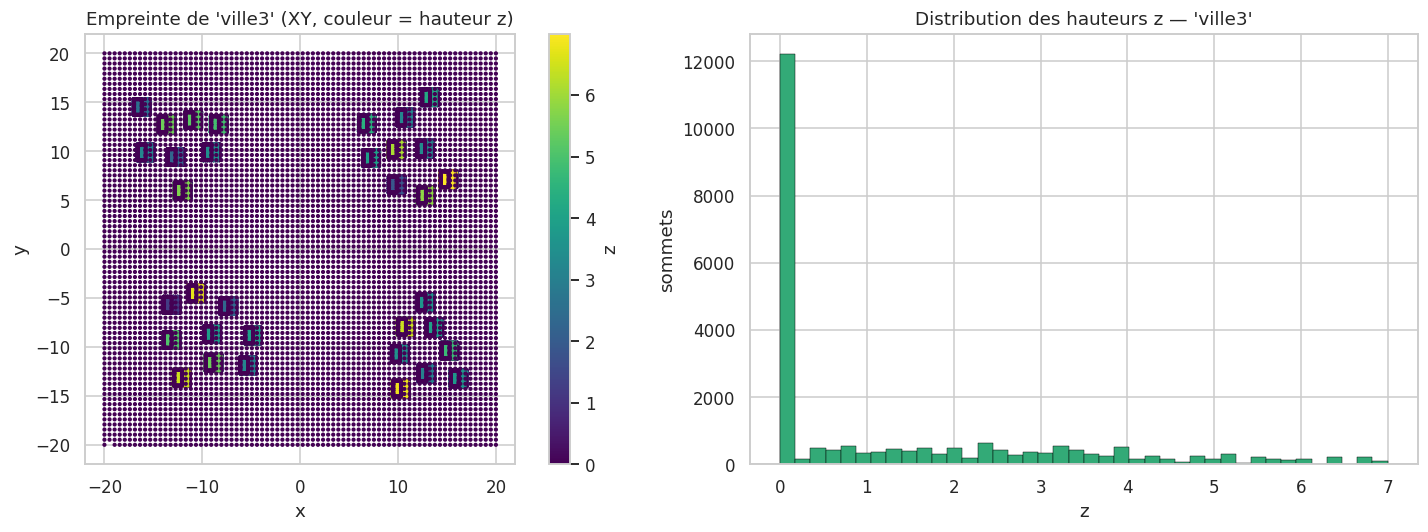

In [8]:
disp = g[["ext_x", "ext_y", "ext_z", "n_groups"]].copy()
disp.columns = ["étendue_x", "étendue_y", "hauteur_z", "n_groups"]
display(disp.style.format({"étendue_x": "{:.2f}", "étendue_y": "{:.2f}", "hauteur_z": "{:.2f}"}))

# Empreinte spatiale d'une ville exemple : sommets en XY colorés par hauteur z.
example = g["n_faces"].idxmax()
verts, faces, _ = parse_ply(BLENDER_DIR / f"{example}.ply")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sc = ax[0].scatter(verts[:, 0], verts[:, 1], c=verts[:, 2], cmap="viridis", s=3)
ax[0].set(title=f"Empreinte de '{example}' (XY, couleur = hauteur z)", xlabel="x", ylabel="y")
ax[0].set_aspect("equal", "box"); fig.colorbar(sc, ax=ax[0], label="z")
ax[1].hist(verts[:, 2], bins=40, color="#3a7", edgecolor="black", lw=.3)
ax[1].set(title=f"Distribution des hauteurs z — '{example}'", xlabel="z", ylabel="sommets")
plt.tight_layout(); plt.show()

## 7 — Implications pour le machine learning sur graphes

Synthèse opérationnelle pour entraîner un GNN (ici un GAT) sur ces maillages.

In [ ]:
print("="*70)
print(" CARACTÉRISATION DES GRAPHES — ce qu'il faut retenir pour le ML")
print("="*70)
print(f"• Type        : graphe d'adjacence de faces d'un maillage triangulé")
print(f"                (nœud = triangle, arête = faces partageant un côté).")
print(f"• Régime      : TRÈS CREUX, degré borné (~{all_deg.mean():.2f}, max théo. 3),")
print(f"                proche planaire → pas de hubs, message passing local homogène.")
print(f"• Taille      : {g.n_faces.min():,}–{g.n_faces.max():,} nœuds/graphe "
      f"(médiane {int(g.n_faces.median()):,}).")
print(f"• Densité     : ~{g.densite.mean():.1e} → matrices d'adjacence creuses,")
print(f"                batching par graphe entier viable (peu d'arêtes).")
print(f"• Connectivité: {int(g.n_composantes.median())} composantes (médiane), plus grande "
      f"= {100*g.frac_plus_grande.median():.1f}% des nœuds.")
print(f"• Diamètre    : ~{int(g.diam_approx.median())} sauts (médiane) >> profondeur GNN")
print(f"                réaliste → des features géométriques GLOBALES (distance/angle")
print(f"                à la source, occlusion) sont indispensables, la seule")
print(f"                propagation locale ne couvre pas le graphe.")
print(f"• Topologie   : {g['manifold_%'].mean():.1f}% d'aretes manifold, "
      f"{g['non_manifold_%'].mean():.2f}% non-manifold a surveiller.")
print(f"• Features    : maillage brut sans labels ; features de nœud à dériver de")
print(f"                la géométrie (cf. dataio._build_node_features, 23 dims).")
print(f"• Split       : 10 villes distinctes → split AU NIVEAU DES VILLES")
print(f"                (train/val/test) pour tester la généralisation géométrique.")
print("="*70)

 CARACTÉRISATION DES GRAPHES — ce qu'il faut retenir pour le ML
• Type        : graphe d'adjacence de faces d'un maillage triangulé
                (nœud = triangle, arête = faces partageant un côté).
• Régime      : TRÈS CREUX, degré borné (~2.82, max théo. 3),
                proche planaire → pas de hubs, message passing local homogène.
• Taille      : 17,367–38,625 nœuds/graphe (médiane 29,179).
• Densité     : ~1.0e-04 → matrices d'adjacence creuses,
                batching par graphe entier viable (peu d'arêtes).
• Connectivité: 153 composantes (médiane), plus grande = 44.1% des nœuds.
• Diamètre    : ~272 sauts (médiane) >> profondeur GNN
                réaliste → des features géométriques GLOBALES (distance/angle
                à la source, occlusion) sont indispensables, la seule
                propagation locale ne couvre pas le graphe.
• Topologie   : 89.1% d'aretes manifold, 0.00% non-manifold a surveiller.
• Features    : maillage brut sans labels ; features de nœud à 